# Karpathy GPT (Lean)
Trimmed copy of `karpathy-build-gpt.ipynb` with the same hardware-aware training flow.

Setup imports/config. Test: run and confirm config prints without errors.

In [19]:
import os
import warnings
import time
from pathlib import Path

import requests
import torch
import lightning as L
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, Callback
from lightning.pytorch.loggers import CSVLogger, WandbLogger
import wandb

from aiml_notebooks import (
    set_seed,
    detect_hardware,
    check_flash_attention,
    flash_attention_func,
    apply_torch_compile,
)

CONFIG = {
    'seed': 1337,
    'batch_size': 64,
    'block_size': 256,
    'n_embed': 384,
    'n_layers': 6,
    'n_heads': 6,
    'dropout': 0.2,
    'learning_rate': 3e-4,
    'max_steps': 5000,
    'eval_interval': 100,
    'eval_iters': 200,
    'checkpoint_dir': 'checkpoints',
    'save_every_n_steps': 500,
    'keep_last_n_checkpoints': 3,
    'resume_from_checkpoint': False,
    'early_stopping_enabled': True,
    'early_stopping_patience': 5,
    'early_stopping_min_delta': 0.005,
    'use_compile': 'default',
    'use_flash_attention': True,
    'use_mixed_precision': True,
    'use_fused_optimizer': True,
    'use_gradient_accumulation': False,
    'gradient_accumulation_steps': 4,
}

set_seed(CONFIG['seed'])
warnings.filterwarnings('ignore', message='.*num_workers.*')
warnings.filterwarnings('ignore', category=UserWarning, module='torch._dynamo')

Checkpoint + W&B resume helpers (disabled by default). Test: enable CONFIG['resume_from_checkpoint']=True to resume and watch for notices.

In [20]:
def latest_checkpoint(path):
    ckpts = sorted(Path(path).glob('**/*.ckpt'), key=lambda p: p.stat().st_mtime, reverse=True)
    return str(ckpts[0]) if ckpts else None

def load_wandb_run_id(path):
    f = Path(path) / 'wandb_run_id.txt'
    return f.read_text().strip() if f.exists() else None

def save_wandb_run_id(path, run_id):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    (path / 'wandb_run_id.txt').write_text(run_id)

RESUME_ENABLED = CONFIG.get('resume_from_checkpoint', False)
CHECKPOINT_PATH = latest_checkpoint(CONFIG['checkpoint_dir']) if RESUME_ENABLED else None
WANDB_RUN_ID = load_wandb_run_id(CONFIG['checkpoint_dir']) if RESUME_ENABLED else None

if RESUME_ENABLED:
    if CHECKPOINT_PATH:
        print(f"Resuming from {CHECKPOINT_PATH}")
    else:
        print("Resume enabled but no checkpoint found")
else:
    print("Checkpoint/W&B resume disabled (CONFIG['resume_from_checkpoint']=False)")


Resuming from checkpoints/epoch=14-step=5865.ckpt


Hardware detection + feature flags. Test: run and verify device/flash/compile summary prints.

In [21]:
hw = detect_hardware(base_batch_size=CONFIG['batch_size'])
CONFIG['batch_size'] = hw.batch_size
CONFIG['use_mixed_precision'] = hw.precision != '32-true'
CONFIG['use_flash_attention'] = hw.use_flash_attention
CONFIG['use_fused_optimizer'] = hw.use_fused_optimizer

compile_setting = CONFIG.get('use_compile', False)
if hw.use_compile:
    if compile_setting is True:
        CONFIG['use_compile'] = 'default'
    elif compile_setting is False:
        CONFIG['use_compile'] = False
    else:
        CONFIG['use_compile'] = compile_setting  # expect string mode
else:
    CONFIG['use_compile'] = False

if hw.gradient_accumulation_steps > 1:
    CONFIG['use_gradient_accumulation'] = True
    CONFIG['gradient_accumulation_steps'] = hw.gradient_accumulation_steps

DEVICE_TYPE = hw.device_type
device = hw.device
precision_type = hw.precision
pin_memory = hw.pin_memory
FLASH_AVAILABLE = check_flash_attention()

compile_label = 'off'
if CONFIG['use_compile']:
    compile_label = CONFIG['use_compile'] if isinstance(CONFIG['use_compile'], str) else 'default'

print(f"Device: {DEVICE_TYPE}, batch size: {CONFIG['batch_size']}, precision: {precision_type}")
print(f"Flash attention: {'on' if FLASH_AVAILABLE and CONFIG['use_flash_attention'] else 'standard'}")
print(f"torch.compile: {compile_label}")


🚀 NVIDIA GPU Detected: NVIDIA GeForce RTX 4090
   Compute Capability: 8.9
   Memory: 25.8 GB
   ✓ Ampere+ architecture detected
   ✓ TF32 enabled for matmul and cuDNN

📊 Final Configuration:
   Device: cuda
   Precision: bf16-mixed
   Batch size: 128
   Mixed precision: ✓
   Flash Attention: ✓ (if installed)
   torch.compile: ✓
   Fused optimizer: ✓
Device: cuda, batch size: 128, precision: bf16-mixed
Flash attention: standard
torch.compile: on


Load tiny Shakespeare and build vocab. Test: run and check token counts/vocab size output.

In [22]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"Tokens: train {len(train_data):,}, val {len(val_data):,}, vocab {vocab_size}")

Tokens: train 1,003,854, val 111,540, vocab 65


Lightning DataModule for random blocks. Test: run and ensure dataloaders construct without errors.

In [23]:
class CharDataset(Dataset):
    def __init__(self, data, block_size, num_samples):
        self.data = data
        self.block_size = block_size
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        i = torch.randint(len(self.data) - self.block_size, (1,)).item()
        x = self.data[i:i + self.block_size]
        y = self.data[i + 1:i + self.block_size + 1]
        return x, y


class ShakespeareDataModule(L.LightningDataModule):
    def __init__(self, train_data, val_data, config, pin_memory):
        super().__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.cfg = config
        self.pin_memory = pin_memory
        self.samples_per_epoch = self.cfg['max_steps'] * self.cfg['batch_size']

    def train_dataloader(self):
        ds = CharDataset(self.train_data, self.cfg['block_size'], self.samples_per_epoch)
        return DataLoader(ds, batch_size=self.cfg['batch_size'], num_workers=0, pin_memory=self.pin_memory)

    def val_dataloader(self):
        ds = CharDataset(self.val_data, self.cfg['block_size'], self.cfg['eval_iters'] * self.cfg['batch_size'])
        return DataLoader(ds, batch_size=self.cfg['batch_size'], num_workers=0, pin_memory=self.pin_memory)


datamodule = ShakespeareDataModule(train_data, val_data, CONFIG, pin_memory)

Transformer building blocks (attention/FFN/block). Test: run to instantiate classes cleanly.

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embed, n_heads, block_size, dropout, use_flash=False):
        super().__init__()
        assert n_embed % n_heads == 0
        self.n_heads = n_heads
        self.head_size = n_embed // n_heads
        self.use_flash = use_flash and FLASH_AVAILABLE
        self.qkv = nn.Linear(n_embed, 3 * n_embed, bias=False)
        self.proj = nn.Linear(n_embed, n_embed)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)
        if not self.use_flash:
            self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_size)
        k = k.view(B, T, self.n_heads, self.head_size)
        v = v.view(B, T, self.n_heads, self.head_size)
        if self.use_flash:
            out = flash_attention_func(
                q, k, v,
                dropout_p=self.attn_dropout.p if self.training else 0.0,
                causal=True,
            ).contiguous().view(B, T, C)
        else:
            q = q.transpose(1, 2)
            k = k.transpose(1, 2)
            v = v.transpose(1, 2)
            att = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)
            att = att.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
            att = torch.nn.functional.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            out = att @ v
            out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj_dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embed, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.GELU(),
            nn.Linear(4 * n_embed, n_embed),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embed, n_heads, block_size, dropout, use_flash=False):
        super().__init__()
        self.sa = MultiHeadAttention(n_embed, n_heads, block_size, dropout, use_flash)
        self.ffwd = FeedForward(n_embed, dropout)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

GPT model definition + optional torch.compile. Test: run to see parameter count print.

In [25]:
class GPTLanguageModel(L.LightningModule):
    def __init__(self, vocab_size, n_embed, n_layers, n_heads, block_size, dropout, learning_rate, use_flash):
        super().__init__()
        self.save_hyperparameters()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.position_embedding_table = nn.Embedding(block_size, n_embed)
        self.blocks = nn.ModuleList([
            Block(n_embed, n_heads, block_size, dropout, use_flash)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(n_embed)
        self.lm_head = nn.Linear(n_embed, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = torch.nn.functional.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    def training_step(self, batch, batch_idx):
        x, y = batch
        _, loss = self(x, y)
        if CONFIG['use_gradient_accumulation']:
            loss = loss / CONFIG['gradient_accumulation_steps']
        self.log('train_loss', loss, on_step=True, prog_bar=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        _, loss = self(x, y)
        perplexity = torch.exp(loss)
        self.log('val_loss', loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        self.log('val_perplexity', perplexity, prog_bar=True, on_epoch=True, batch_size=x.size(0))

    def configure_optimizers(self):
        if CONFIG['use_fused_optimizer'] and DEVICE_TYPE == 'cuda':
            return torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate, fused=True)
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate)

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = torch.nn.functional.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


model = GPTLanguageModel(
    vocab_size=vocab_size,
    n_embed=CONFIG['n_embed'],
    n_layers=CONFIG['n_layers'],
    n_heads=CONFIG['n_heads'],
    block_size=CONFIG['block_size'],
    dropout=CONFIG['dropout'],
    learning_rate=CONFIG['learning_rate'],
    use_flash=CONFIG['use_flash_attention'],
)

compile_setting = CONFIG.get('use_compile', False)
if compile_setting:
    compile_mode = 'default' if compile_setting is True else str(compile_setting)
    print(f"Applying torch.compile (mode={compile_mode})...")
    model = apply_torch_compile(model, mode=compile_mode)

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

Applying torch.compile with mode='default'...
  (This may take a minute on first run)
✓ torch.compile applied successfully
Parameters: 10,788,929


Trainer, loggers, checkpoints, early stopping. Test: run to build trainer without error.

In [26]:
class KeepRecentCheckpoints(Callback):
    def __init__(self, checkpoint_dir, keep_last_n):
        super().__init__()
        self.checkpoint_dir = Path(checkpoint_dir)
        self.keep_last_n = keep_last_n

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if not self.checkpoint_dir.exists():
            return
        ckpts = sorted(self.checkpoint_dir.glob('step-*.ckpt'), key=lambda p: p.stat().st_mtime, reverse=True)
        for ckpt in ckpts[self.keep_last_n:]:
            ckpt.unlink(missing_ok=True)


accumulate_grad_batches = CONFIG['gradient_accumulation_steps'] if CONFIG['use_gradient_accumulation'] else 1

best_checkpoint = ModelCheckpoint(
    dirpath=CONFIG['checkpoint_dir'],
    filename='best-{epoch:02d}-{step:06d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_last=False,
    auto_insert_metric_name=False,
)

periodic_checkpoint = ModelCheckpoint(
    dirpath=CONFIG['checkpoint_dir'],
    filename='step-{step:06d}-{epoch:02d}',
    every_n_train_steps=CONFIG['save_every_n_steps'],
    save_top_k=-1,
    save_last=True,
    auto_insert_metric_name=False,
    enable_version_counter=False,
)

callbacks = [best_checkpoint, periodic_checkpoint, KeepRecentCheckpoints(CONFIG['checkpoint_dir'], CONFIG['keep_last_n_checkpoints'])]

if CONFIG['early_stopping_enabled']:
    callbacks.append(EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['early_stopping_patience'],
        min_delta=CONFIG['early_stopping_min_delta'],
        mode='min',
        check_on_train_epoch_end=False,
    ))

wandb_logger = None
if WANDB_RUN_ID:
    wandb.init(project='gpt-shakespeare', id=WANDB_RUN_ID, resume='must', config=CONFIG)
    wandb_logger = WandbLogger(experiment=wandb.run, log_model=False)
else:
    wandb_logger = WandbLogger(project='gpt-shakespeare', config=CONFIG, log_model=False)
    save_wandb_run_id(CONFIG['checkpoint_dir'], wandb_logger.experiment.id)

csv_logger = CSVLogger('logs', name=f'gpt_{DEVICE_TYPE}')
loggers = [csv_logger]
if wandb_logger is not None:
    loggers.append(wandb_logger)

trainer = L.Trainer(
    max_steps=CONFIG['max_steps'],
    val_check_interval=CONFIG['eval_interval'],
    accelerator='auto',
    devices=1,
    precision=precision_type if CONFIG['use_mixed_precision'] else '32-true',
    logger=loggers,
    callbacks=callbacks,
    enable_progress_bar=True,
    log_every_n_steps=1,
    accumulate_grad_batches=accumulate_grad_batches,
    benchmark=(DEVICE_TYPE == 'cuda'),
)

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training execution. Test: run to start training; set CONFIG['resume_from_checkpoint']=True to resume from latest checkpoint.

In [27]:
start_time = time.time()
trainer.fit(model, datamodule, ckpt_path=CHECKPOINT_PATH)
elapsed = time.time() - start_time
print(f"Training wall time: {elapsed:.2f}s ({elapsed/60:.2f} min)")


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/tsilva/repos/tsilva/aiml-notebooks/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name                     | Type       | Params | Mode 
----------------------------------------------------------------
0 | token_embedding_table    | Embedding  | 25.0 K | train
1 | position_embedding_table | Embedding  | 98.3 K | train
2 | blocks                   | ModuleList | 10.6 M | train
3 | ln_f                     | LayerNorm  | 768    | train
4 | lm_head                  | Linear     | 25.0 K | train
---------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

W1122 18:38:35.539000 24792 torch/_dynamo/convert_frame.py:1358] [1/8] torch._dynamo hit config.recompile_limit (8)
W1122 18:38:35.539000 24792 torch/_dynamo/convert_frame.py:1358] [1/8]    function: 'log' (/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/core/module.py:384)
W1122 18:38:35.539000 24792 torch/_dynamo/convert_frame.py:1358] [1/8]    last reason: 1/7: name == 'val_perplexity'                                 # if add_dataloader_idx and "/dataloader_idx_" in name:  # lightning/pytorch/core/module.py:477 in log
W1122 18:38:35.539000 24792 torch/_dynamo/convert_frame.py:1358] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1122 18:38:35.539000 24792 torch/_dynamo/convert_frame.py:1358] [1/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Plot metrics after training. Test: run to show loss/perplexity curves and final stats.

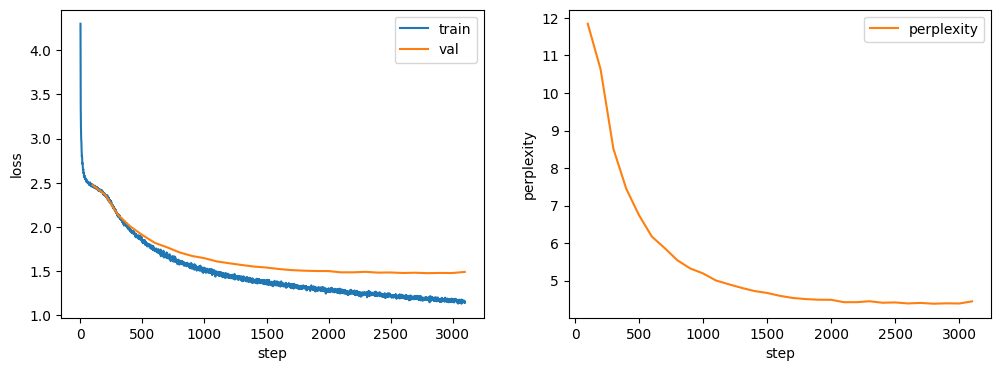

Final val loss: 1.4917
Final val perplexity: 4.45


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"{csv_logger.log_dir}/metrics.csv")
train = metrics[['step', 'train_loss']].dropna()
val = metrics[['step', 'val_loss']].dropna()
perplexity = metrics[['step', 'val_perplexity']].dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train['step'], train['train_loss'], label='train')
ax[0].plot(val['step'], val['val_loss'], label='val')
ax[0].set_xlabel('step')
ax[0].set_ylabel('loss')
ax[0].legend()
ax[1].plot(perplexity['step'], perplexity['val_perplexity'], label='perplexity', color='tab:orange')
ax[1].set_xlabel('step')
ax[1].set_ylabel('perplexity')
ax[1].legend()
plt.show()

if not val.empty:
    print(f"Final val loss: {val['val_loss'].iloc[-1]:.4f}")
if not perplexity.empty:
    print(f"Final val perplexity: {perplexity['val_perplexity'].iloc[-1]:.2f}")

Generate sample text. Test: run to produce a 500-token sample output.

In [29]:
model_to_use = model._orig_mod if hasattr(model, '_orig_mod') else model
model_to_use = model_to_use.to(device).eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
with torch.no_grad():
    generated = model_to_use.generate(context, max_new_tokens=500)[0].tolist()
print(decode(generated))

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/_inductor/lowering.py:7242: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/_inductor/lowering.py:7242: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(



Sea, I prithee, and still the greatness and play
With particular hatred in the regard's rage;
Or else that Titus Lartius married Tarquin;
My profess and have been or painted,
And saying hereafter the heart of their winter.

QUEEN:
O most old Richard, and I love them knavelly
Honour than the Paris? is Hermione's daughter,
And for his attoming for our general gates?

QUEEN MARGARET:
Ah, little for his newship frailing tears,
Are is no sake, but do not being custom.

KING EDWARD IV:
That stays me, 
